<a href="https://colab.research.google.com/github/paplpap/zero-to-AI/blob/main/python_pandas1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task

파이썬 학습자에게 Pandas를 단계별로 가르치기 위한 전체 학습 과정을 요약합니다.

### Pandas, 왜 필요할까요? (엑셀보다 좋은 점!)

#### Subtask:
Pandas가 무엇인지, 왜 필요한지, 그리고 엑셀과 비교하여 어떤 장점이 있는지 개념적으로 설명합니다.

---

#### 1. Pandas는 무엇인가요? 데이터 다루기의 핵심 기능!

Pandas는 Python에서 데이터를 다루고 분석하는 데 사용되는 강력한 라이브러리입니다. `DataFrame`과 `Series`라는 두 가지 핵심 데이터 구조를 제공하며, 이를 통해 다양한 형태의 데이터를 효율적으로 처리할 수 있습니다.

*   **DataFrame**: 스프레드시트나 SQL 테이블처럼 행과 열로 구성된 2차원 테이블 형태의 데이터 구조입니다. 각 열은 서로 다른 데이터 타입을 가질 수 있습니다.
**그냥 엑셀이라고 생각하시면 됩니다**

*   **Series**: 단일 열로 구성된 1차원 배열과 유사한 데이터 구조입니다.

Pandas는 다음과 같은 핵심 기능들을 제공합니다.
*   **데이터 불러오기/저장하기**: CSV, Excel, SQL 데이터베이스, JSON 등 다양한 형식의 데이터를 쉽게 불러오고 저장할 수 있습니다.
*   **데이터 선택 및 필터링**: 원하는 행과 열을 편리하게 선택하고 조건에 따라 데이터를 필터링할 수 있습니다.
*   **데이터 정제 및 변환**: 누락된 값 처리, 중복 값 제거, 데이터 타입 변경, 새로운 열 생성 등 데이터 전처리 작업을 효율적으로 수행할 수 있습니다.
*   **데이터 집계 및 요약**: 평균, 합계, 개수 등 통계 요약을 계산하고, 데이터를 그룹별로 집계하여 인사이트를 도출할 수 있습니다.
*   **데이터 결합**: 여러 데이터를 병합하거나 조인하여 하나의 데이터셋으로 만들 수 있습니다.



그러면 csv데이터를 직접 만들어 보고 저장한후 다시 열어보는 과정을 거쳐봅시다.


In [1]:
csv_data = """Name,Age,City
Alice,30,New York
Bob,24,London
Charlie,35,Paris
David,28,New York
Eve,22,London"""

file_name = "sample_data.csv"

with open(file_name, "w", encoding="utf-8") as f:
    f.write(csv_data)

print(f"'{file_name}' 파일이 성공적으로 생성되었습니다.")


'sample_data.csv' 파일이 성공적으로 생성되었습니다.


## CSV 파일 불러오기 코드

### Subtask:
pandas.read_csv() 함수를 사용하여 로컬 환경에 있는 CSV 파일을 DataFrame으로 불러오는 코드를 작성합니다. 파일 경로 지정 방법에 대해 설명합니다.


In [6]:
import pandas as pd
print("Pandas 라이브러리를 임포트했습니다.")

df = pd.read_csv(file_name)
print(f"'{file_name}' 파일을 DataFrame으로 성공적으로 불러왔습니다.")
print(f"df 변수의 타입: {type(df)}")

print("---결과---")
df.head()

Pandas 라이브러리를 임포트했습니다.
'sample_data.csv' 파일을 DataFrame으로 성공적으로 불러왔습니다.
df 변수의 타입: <class 'pandas.core.frame.DataFrame'>
---결과---


,Name,Age,City
0,Alice,30,New York
1,Bob,24,London
2,Charlie,35,Paris
3,David,28,New York
4,Eve,22,London


이처럼 ','를 기반으로 정보가 나누어지는 데이터를 csv라고 함을 알 수 있고, 데이터의 저장 및 불러오기를 완료 하였습니다.


이제 여러분의 엑셀데이터를 가져올 수 있습니다.

## 데이터 정보확인

우선 분석할 데이터를 가져온 이후 잘 열리는것이 확인되면, 대부분의 경우 기본 정보와 기술통계량을 봐야 합니다.

방법으로는 .info() , .describe() 메서드를 사용하는 것 입니다.


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    5 non-null      object
 1   Age     5 non-null      int64 
 2   City    5 non-null      object
dtypes: int64(1), object(2)
memory usage: 252.0+ bytes


df.info() 는 각 열의 이름과 데이터 타입(object, int, float, bool .etc) 그리고 null값(빈 값)을 확인할 수 있습니다.

여기서 결측치가 얼마나 있는지, 데이터 타입을 보고 어떤식으로 데이터를 처리할지 생각할 수 있습니다.

In [8]:
df.describe()

,Age
count,5.000000
mean,27.800000
std,5.118594
min,22.000000
25%,24.000000
50%,28.000000
75%,30.000000
max,35.000000


df.describe() 는 숫자형 데이터의 갯수, 평균, 표준편차, 최솟값, 최댓값 등 주요 통계량을 확인할 수 있습니다.

이상치(outlier)의 유무를 확인할 수 있습니다.

이상치가 있으면 평균값이 크게 흔들립니다. 따라서 가중평균을 사용하는등의 방식을 이용하죠

## EDA 탐색적 데이터 분석

 그래프나 통계적 방법 등을 통해 데이터를 다양한 각도에서 살펴보고 가공하는 과정을 말합니다.

1977년 미국의 통계학자 존 튜키(John Tukey)가 제안한 개념으로, 단순히 가설을 검정하는 것을 넘어

"데이터가 우리에게 무엇을 말하고 있는가?"를 찾아내는 정찰 활동과 같습니다.

**결측치 확인**


`df.isnull().sum()`을 사용하여 각 열에 결측치(누락된 값)가 있는지 확인하고 그 수를 파악합니다. 이는 데이터 전처리 과정에서 중요합니다.


In [11]:
df.isnull().sum()

,0
Name,0
Age,0
City,0


**특정 컬럼의 고유 값 및 빈도 확인**


특정 컬럼(예: 'City')의 고유한 값과 각 값의 빈도를 `value_counts()` 메서드를 사용하여 확인합니다. 이는 범주형 데이터의 분포를 이해하는 데 도움이 됩니다.

In [12]:
df['City'].value_counts()

,count
City,
New York,2
London,2
Paris,1


**고유 값 및 빈도 확인**


특정 컬럼(예: 'City')의 고유한 값들을 `unique()` 메서드를 사용하여 확인합니다. 이는 범주형 데이터의 종류를 파악하는 데 도움이 됩니다.


In [13]:
df['City'].unique()

array(['New York', 'London', 'Paris'], dtype=object)

##kaggle 데이터셋으로 시각화 해보기

Iris 데이터셋을 Seaborn에서 불러와 Pandas DataFrame으로 변환하고, `df.head()`, `df.info()`, `df.describe()`를 사용하여 데이터의 기본 정보를 확인한 뒤, 히스토그램/KDE 플롯, Pair 플롯, Box/Violin 플롯을 통해 데이터 분포와 변수 간의 관계를 시각적으로 분석합니다.

In [14]:
import seaborn as sns
print("Seaborn 라이브러리를 임포트했습니다.")

df = sns.load_dataset('iris')
print("'iris' 데이터셋을 DataFrame으로 성공적으로 불러왔습니다.")

print("---결과---")
df.head()

Seaborn 라이브러리를 임포트했습니다.
'iris' 데이터셋을 DataFrame으로 성공적으로 불러왔습니다.
df 변수의 타입: <class 'pandas.core.frame.DataFrame'>
---결과---


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 데이터 기본 정보 확인

### Subtask:
불러온 Iris 데이터셋의 상위 5개 행(df.head()), 전체 정보(df.info()), 그리고 기술 통계량(df.describe())을 확인하여 데이터의 구조와 주요 특징을 파악합니다.


### 데이터 정보 확인 (`df.info()`)

`df.info()`를 사용하여 DataFrame의 각 컬럼명, Non-Null 값 개수, 데이터 타입 및 메모리 사용량 등 기본 정보를 확인합니다. 이를 통해 데이터의 누락된 값 유무와 각 컬럼의 데이터 타입을 파악할 수 있습니다.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### 데이터 기술 통계량 확인 (`df.describe()`)

`df.describe()`를 사용하여 DataFrame의 숫자형 컬럼에 대한 기술 통계량(개수, 평균, 표준편차, 최솟값, 25%, 50%, 75% 분위수, 최댓값)을 확인합니다. 이는 데이터의 분포와 잠재적 이상치를 파악하는 데 도움이 됩니다.

In [16]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 데이터 시각화 (EDA)

### Subtask:
Iris 데이터셋의 특징을 파악하기 위해 히스토그램/KDE 플롯, Pair 플롯, Box/Violin 플롯을 생성하여 데이터 분포와 변수 간의 관계를 시각적으로 분석합니다. 각 시각화에는 적절한 범례를 포함합니다.


matplotlib.pyplot을 plt로 임포트했습니다.

--- 각 수치형 변수의 히스토그램/KDE 플롯 (species별) ---


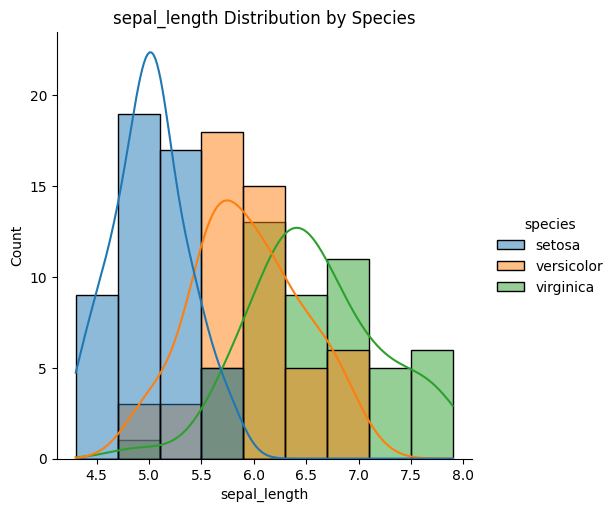

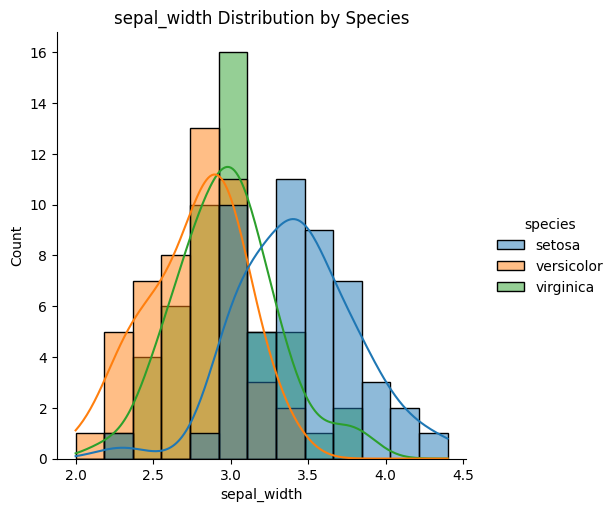

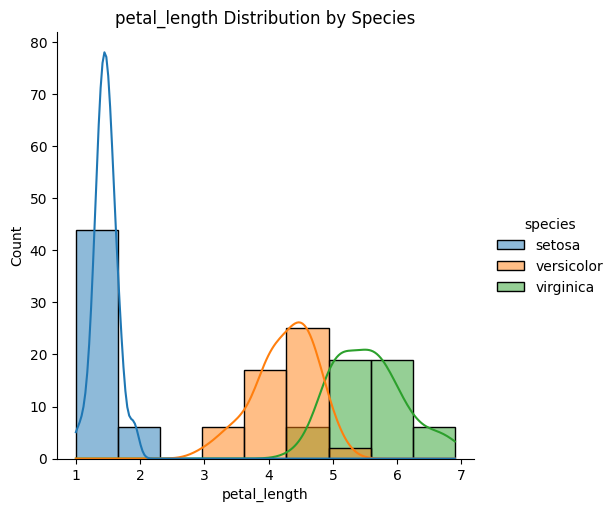

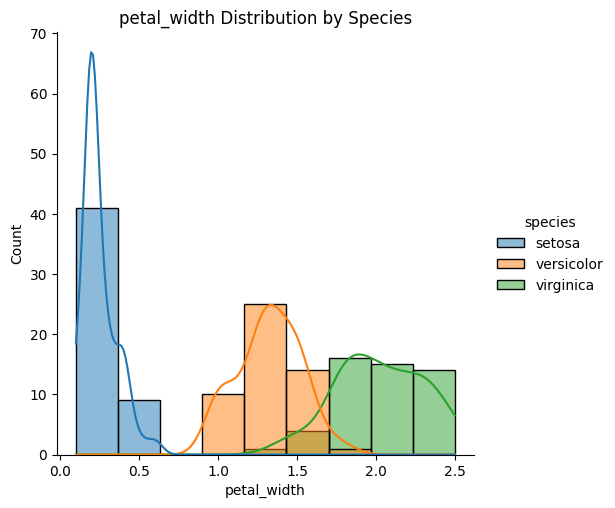


--- 모든 수치형 변수 쌍 간의 Pair 플롯 (species별) ---


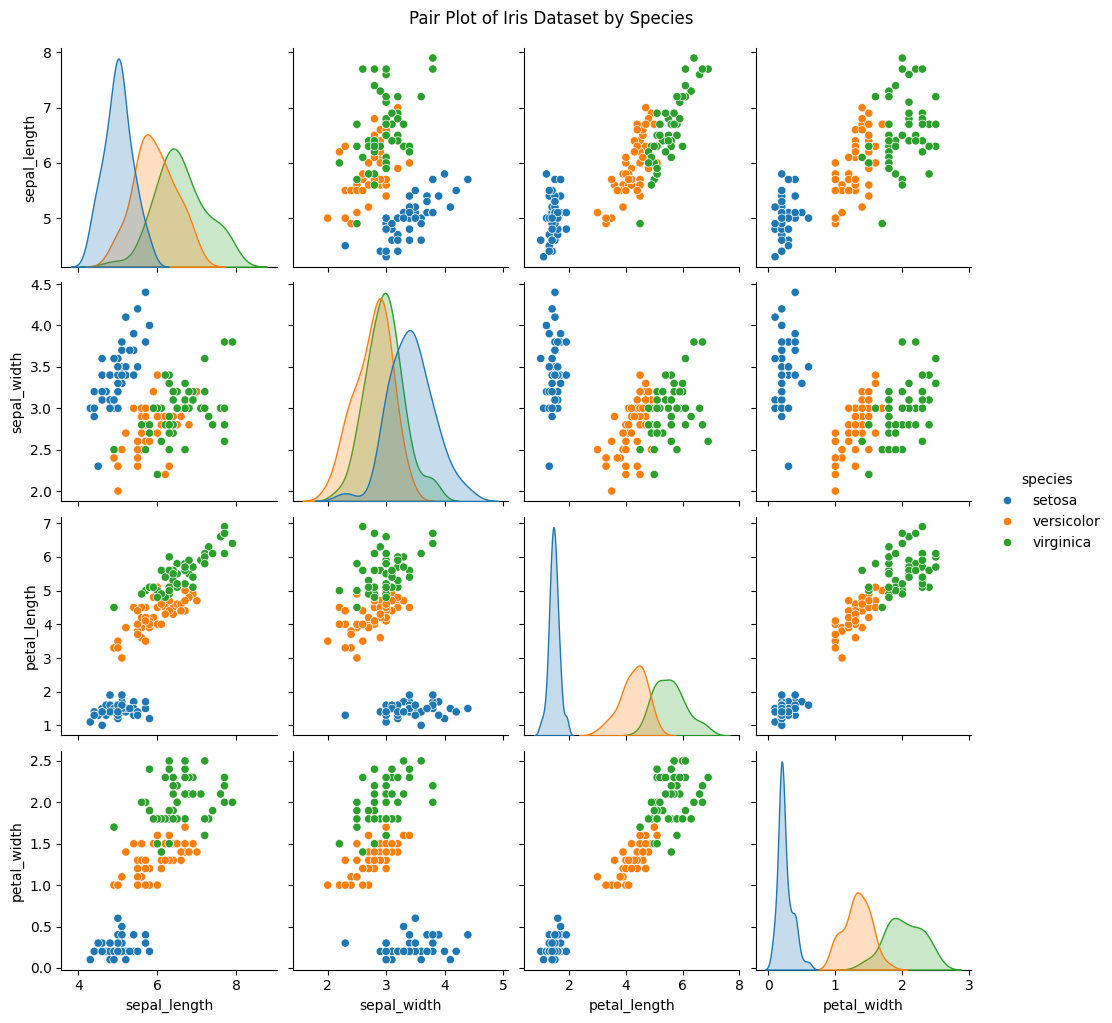


--- 각 수치형 변수의 Box 플롯 (species별) ---


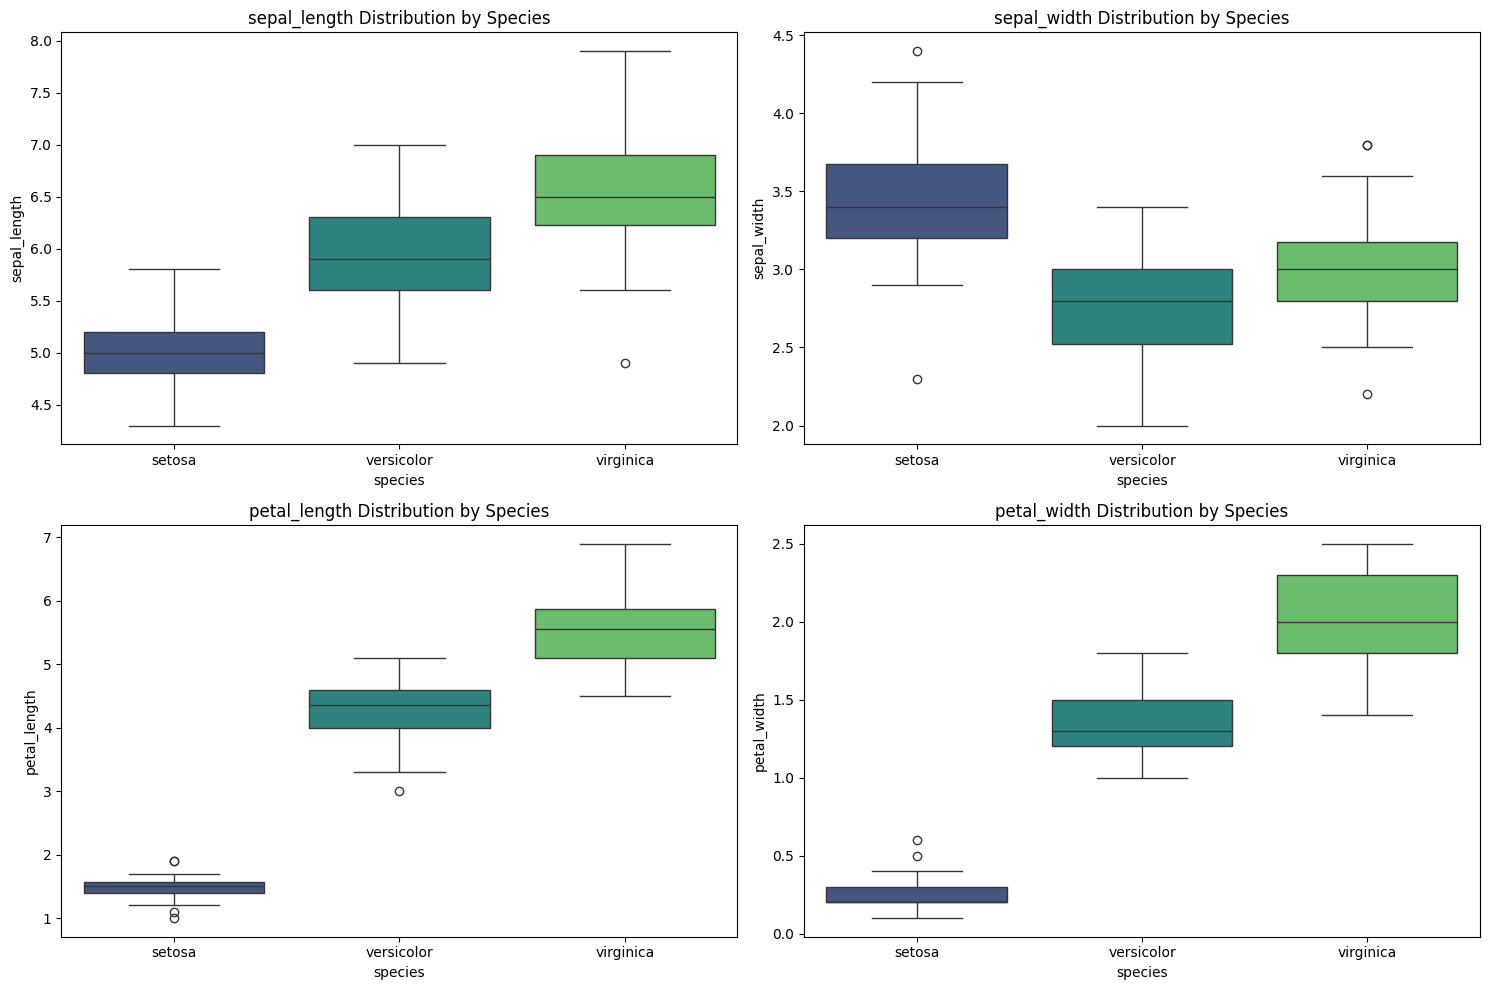

In [17]:
import matplotlib.pyplot as plt
print("matplotlib.pyplot을 plt로 임포트했습니다.")

# 2. 히스토그램/KDE 플롯 (종별)
print("\n--- 각 수치형 변수의 히스토그램/KDE 플롯 (species별) ---")
for column in ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']:
    sns.displot(data=df, x=column, kde=True, hue='species', kind='hist')
    plt.title(f'{column} Distribution by Species')
    plt.show()

# 3. Pair 플롯 (변수 간의 관계)
print("\n--- 모든 수치형 변수 쌍 간의 Pair 플롯 (species별) ---")
sns.pairplot(data=df, hue='species')
plt.suptitle('Pair Plot of Iris Dataset by Species', y=1.02) # 타이틀 겹침 방지
plt.show()

# 4. Box 또는 Violin 플롯 (종별 분포 비교)
print("\n--- 각 수치형 변수의 Box 플롯 (species별) ---")
plt.figure(figsize=(15, 10))
for i, column in enumerate(['sepal_length', 'sepal_width', 'petal_length', 'petal_width']):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df, x='species', y=column, hue='species', palette='viridis', legend=False)
    plt.title(f'{column} Distribution by Species')
plt.tight_layout()
plt.show()


## 마치며

정말 정규 과정으로 수업처럼 어떤 열에 들어가기, 몇번 데이터 바꾸기 이런 방식으로 접근하기 보다. 생성형 AI를 통해 빠르게 예시 하나를 분석해 보는것을 목표로 진행해 보았다.

마지막의 시각화 부분은 `.displot()` 의 파라미터를 바꿧을때 그래프가 어떻게 바뀌는지 알아보는것이 좋다.

이처럼 이 글을 보면서 자신이 가진 데이터를 간단히 분석하는 방법을 알아보았다.